<div align="center">

# Laboratorio No. 1

## Preparación de un corpus y Análisis Exploratorio de Datos

<br>

**Curso:** Natual Language Processing
**Estudiante:** Jose Tánchez  
**Carné:** 20230005  

<br>

---

### Exploración, preparación y análisis del corpus  
### Spanish News Classification

</div>

# 2. Exploración inicial del corpus

Antes de aplicar cualquier proceso de normalización, se realizará una exploración de los datos para conocer varias cosas.

> En esta sección el corpus únicamente será explorado. No se modificarán ni eliminarán datos.

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display

archivos_csv = list(Path(".").glob("*.csv"))

if not archivos_csv:
    raise FileNotFoundError(
        "No se encontró ningún archivo CSV. "
        "Coloca el corpus en la misma carpeta que el notebook."
    )

ruta_corpus = archivos_csv[0]

try:
    df = pd.read_csv(ruta_corpus, sep=None, engine="python")
except UnicodeDecodeError:
    df = pd.read_csv(
        ruta_corpus,
        sep=None,
        engine="python",
        encoding="latin-1"
    )

print(f"Archivo cargado: {ruta_corpus.name}")
print(f"Dimensiones del corpus: {df.shape}")

display(df.head())

Archivo cargado: df_total.csv
Dimensiones del corpus: (1217, 3)


,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


In [2]:
cantidad_documentos = df.shape[0]

print(f"Cantidad total de documentos: {cantidad_documentos:,}")

Cantidad total de documentos: 1,217


## 2.1 Cantidad de documentos

El corpus contiene un total de **[1217] documentos**.

Para este análisis, cada fila del conjunto de datos se considera un documento o noticia individual.

In [3]:
resumen_columnas = pd.DataFrame({
    "Columna": df.columns,
    "Tipo de dato": df.dtypes.astype(str).values,
    "Valores no vacíos": df.notna().sum().values,
    "Valores vacíos": df.isna().sum().values,
    "Ejemplo": [
        df[columna].dropna().iloc[0]
        if not df[columna].dropna().empty
        else "Sin datos"
        for columna in df.columns
    ]
})

print(f"El corpus contiene {len(df.columns)} columnas.")

display(resumen_columnas)

El corpus contiene 3 columnas.


,Columna,Tipo de dato,Valores no vacíos,Valores vacíos,Ejemplo
0,url,str,1217,0,https://www.larepublica.co/redirect/post/3201905
1,news,str,1217,0,Durante el foro La banca articulador empresari...
2,Type,str,1217,0,Otra


## 2.2 Columnas del corpus

El conjunto de datos contiene **[3] columnas**:

| Columna | Información almacenada |
|---|---|
| `[URL]` | [Esta columan contiene la url de donde salio la noticia] |
| `[NEWS]` | [Esta columna contiene la noticia como tal] |
| `[TYPE]` | [Esta columna contiene el tipo de noticia de la que se trata] |

Cada fila representa una noticia, mientras que las columnas almacenan sus diferentes características, como el texto, el título o la categoría a la que pertenece.

In [4]:
distribucion_categorias = df["Type"].value_counts().reset_index()
distribucion_categorias.columns = ["Categoría", "Cantidad de noticias"]

distribucion_categorias["Porcentaje"] = (
    distribucion_categorias["Cantidad de noticias"] / len(df) * 100
).round(2)

print(f"Cantidad total de categorías: {df['Type'].nunique()}")

display(distribucion_categorias)

Cantidad total de categorías: 7


,Categoría,Cantidad de noticias,Porcentaje
0,Macroeconomia,340,27.94
1,Alianzas,247,20.30
2,Innovacion,195,16.02
3,Regulaciones,142,11.67
4,Sostenibilidad,137,11.26
5,Otra,130,10.68
6,Reputacion,26,2.14


## 2.3 Categorías del corpus

La columna **`Type`** indica la categoría a la que pertenece cada noticia.

El corpus contiene un total de **[7] categorías diferentes**. La distribución de las noticias por categoría es la siguiente:

| Categoría | Cantidad de noticias | Porcentaje |
|---|---:|---:|
| [Macroeconomia] | [340] | [27.94]% |
| [Alianzas] | [247] | [20.3]% |
| [Inovacion] | [195] | [16.02]% |
| [Regulaciones] | [142] | [11.67]% |
| [Sostenibilidad] | [137] | [11.26]% |
| [Otra] | [130] | [10.68]% |
| [Reputacion] | [26] | [2.14]% |

La categoría con más noticias es **[Macroeconomia]**, con **[340] documentos**, mientras que la categoría con menos noticias es **[Reputacion]**, con **[26] documentos**.

Esta distribución permite observar si las categorías del corpus se encuentran equilibradas o si algunas contienen muchas más noticias que otras.

In [5]:
# Crear una copia temporal para considerar los textos vacíos como valores nulos
df_revision = df.replace(r"^\s*$", pd.NA, regex=True)

# Revisar valores vacíos
filas_con_vacios = df_revision.isna().any(axis=1).sum()
filas_completamente_vacias = df_revision.isna().all(axis=1).sum()

vacios_por_columna = df_revision.isna().sum()

# Revisar duplicados
filas_duplicadas_completas = df.duplicated().sum()
urls_duplicadas = df["url"].duplicated().sum()
noticias_duplicadas = df["news"].duplicated().sum()

# Los valores repetidos en Type son normales porque representan categorías
tipos_repetidos = df["Type"].duplicated().sum()

resumen_calidad = pd.DataFrame({
    "Verificación": [
        "Filas con al menos un valor vacío",
        "Filas completamente vacías",
        "Filas completamente duplicadas",
        "URL duplicadas",
        "Noticias duplicadas",
        "Valores repetidos en Type"
    ],
    "Cantidad": [
        filas_con_vacios,
        filas_completamente_vacias,
        filas_duplicadas_completas,
        urls_duplicadas,
        noticias_duplicadas,
        tipos_repetidos
    ]
})

print("Valores vacíos por columna:")
display(vacios_por_columna.to_frame(name="Cantidad de valores vacíos"))

print("Resumen de valores vacíos y duplicados:")
display(resumen_calidad)

Valores vacíos por columna:


,Cantidad de valores vacíos
url,0
news,4
Type,0


Resumen de valores vacíos y duplicados:


,Verificación,Cantidad
0,Filas con al menos un valor vacío,4
1,Filas completamente vacías,0
2,Filas completamente duplicadas,75
3,URL duplicadas,116
4,Noticias duplicadas,79
5,Valores repetidos en Type,1210


## 2.4 Valores vacíos y duplicados

Para evaluar la calidad del corpus, se revisaron los valores vacíos y las duplicaciones presentes en cada una de sus columnas.

### Valores vacíos

| Verificación | Cantidad |
|---|---:|
| Filas con al menos un valor vacío | **[4]** |
| Filas completamente vacías | **[0]** |

La distribución de valores vacíos por columna fue la siguiente:

| Columna | Valores vacíos |
|---|---:|
| `URL` | [0] |
| `News` | [4] |
| `Type` | [0] |

### Valores duplicados

| Verificación | Cantidad |
|---|---:|
| Filas completamente duplicadas | **[75]** |
| URL duplicadas | **[116]** |
| Noticias duplicadas | **[79]** |

Las **filas completamente duplicadas** son aquellas en las que los valores de `URL`, `News` y `Type` son iguales.

Las **URL duplicadas** indican que una misma dirección aparece más de una vez, mientras que las **noticias duplicadas** representan contenidos textuales repetidos dentro del corpus.

La columna `Type` también contiene valores repetidos, pero esto es normal, ya que varias noticias pueden pertenecer a una misma categoría. Por esta razón, sus repeticiones no se consideran un problema de duplicación.

En esta etapa únicamente se identificaron los posibles problemas del corpus. Todavía no se eliminaron filas ni se modificaron los datos.

# 3. Preparación del corpus

En esta sección se aplicará un proceso de normalización sobre el contenido de las noticias.

El procedimiento se realizará en el siguiente orden:

1. **Tokenización:** separación del texto en unidades individuales.
2. **Conversión a minúsculas:** unificación de palabras escritas con diferentes combinaciones de mayúsculas y minúsculas.
3. **Eliminación de puntuación:** eliminación de puntos, comas, signos de interrogación y otros símbolos.
4. **Eliminación de stopwords:** eliminación de palabras frecuentes que aportan poca información al análisis.
5. **Lematización:** reducción de las palabras a su forma base o forma de diccionario.

> Después de cada etapa se calculará la cantidad total de **tokens** y la cantidad de **tipos**, es decir, palabras diferentes.

In [6]:
import re
import nltk
import spacy
import pandas as pd

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from spacy.tokens import Doc
from IPython.display import display


nlp = spacy.load(
    "es_core_news_sm",
    disable=["parser", "ner"]
)

print("Librerías y modelo de español cargados correctamente.")

Librerías y modelo de español cargados correctamente.


In [7]:
# Crear una copia del corpus original
corpus = df.copy()

# Reemplazar posibles valores vacíos por texto vacío
corpus["news"] = corpus["news"].fillna("").astype(str)

print(f"Cantidad de documentos que serán procesados: {len(corpus):,}")

display(corpus[["url", "news", "Type"]].head())

Cantidad de documentos que serán procesados: 1,217


,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


In [8]:
# Diccionario donde se almacenarán los resultados
resultados_normalizacion = {}


def contar_tokens_y_tipos(columna_tokens):
    """
    Cuenta la cantidad total de tokens y tipos
    presentes en una columna de listas.
    """

    cantidad_tokens = 0
    vocabulario = set()

    for documento in columna_tokens:
        cantidad_tokens += len(documento)
        vocabulario.update(documento)

    cantidad_tipos = len(vocabulario)

    return cantidad_tokens, cantidad_tipos


def registrar_resultado(etapa, columna_tokens):
    """
    Calcula y guarda la cantidad de tokens y tipos
    obtenidos en una etapa del proceso.
    """

    tokens, tipos = contar_tokens_y_tipos(columna_tokens)

    resultados_normalizacion[etapa] = {
        "Tokens": tokens,
        "Tipos": tipos
    }

    print(f"Etapa: {etapa}")
    print(f"Tokens totales: {tokens:,}")
    print(f"Tipos diferentes: {tipos:,}")

## 3.1 Tokenización

La tokenización consiste en dividir cada noticia en unidades más pequeñas llamadas **tokens**.

En esta primera etapa se conservan las palabras, los números y los signos de puntuación tal como aparecen en el texto original.

In [9]:
# Dividir cada noticia en tokens
corpus["tokens_tokenizados"] = corpus["news"].apply(
    lambda texto: word_tokenize(
        texto,
        language="spanish"
    )
)

# Contar tokens y tipos
registrar_resultado(
    "1. Tokenización",
    corpus["tokens_tokenizados"]
)

# Mostrar un ejemplo
print("\nPrimeros 40 tokens de la primera noticia:")
print(corpus["tokens_tokenizados"].iloc[0][:40])

Etapa: 1. Tokenización
Tokens totales: 665,592
Tipos diferentes: 38,947

Primeros 40 tokens de la primera noticia:
['Durante', 'el', 'foro', 'La', 'banca', 'articulador', 'empresarial', 'para', 'el', 'desarrollo', 'sostenible', 'el', 'director', 'de', 'sostenibilidad', 'y', 'clientes', 'globales', 'de', 'BBVA', 'en', 'Colombia', 'Andrés', 'García', 'aseguró', 'que', 'es', 'importante', 'entender', 'que', 'la', 'sostenibilidad', 'no', 'la', 'podemos', 'asociar', 'a', 'mayores', 'costos', '.']


### Resultado de la tokenización

Después de tokenizar todas las noticias se obtuvieron:

- **Tokens totales:** `[665592]`
- **Tipos diferentes:** `[38947]`

En esta etapa todavía se conservan las mayúsculas, las minúsculas y los signos de puntuación. Por esta razón, palabras como `Hola` y `hola` todavía son consideradas tipos diferentes.

## 3.2 Conversión a minúsculas

En esta etapa todos los tokens se convierten a minúsculas.

Esto permite unificar palabras que tienen el mismo significado, pero que se encuentran escritas de manera diferente debido al uso de mayúsculas.

Por ejemplo, `Hola`, `HOLA` y `hola` pasan a ser el mismo tipo: `hola`.

In [10]:
# Convertir cada token a minúsculas
corpus["tokens_minusculas"] = corpus["tokens_tokenizados"].apply(
    lambda tokens: [
        token.lower()
        for token in tokens
    ]
)

# Contar tokens y tipos
registrar_resultado(
    "2. Minúsculas",
    corpus["tokens_minusculas"]
)

# Mostrar un ejemplo
print("\nPrimeros 40 tokens en minúsculas:")
print(corpus["tokens_minusculas"].iloc[0][:40])

Etapa: 2. Minúsculas
Tokens totales: 665,592
Tipos diferentes: 36,099

Primeros 40 tokens en minúsculas:
['durante', 'el', 'foro', 'la', 'banca', 'articulador', 'empresarial', 'para', 'el', 'desarrollo', 'sostenible', 'el', 'director', 'de', 'sostenibilidad', 'y', 'clientes', 'globales', 'de', 'bbva', 'en', 'colombia', 'andrés', 'garcía', 'aseguró', 'que', 'es', 'importante', 'entender', 'que', 'la', 'sostenibilidad', 'no', 'la', 'podemos', 'asociar', 'a', 'mayores', 'costos', '.']


### Resultado de la conversión a minúsculas

Después de convertir todos los tokens a minúsculas quedaron:

- **Tokens totales:** `[665592]`
- **Tipos diferentes:** `[36099]`

La cantidad total de tokens no cambia porque todavía no se ha eliminado ningún elemento. Sin embargo, la cantidad de tipos puede disminuir porque las palabras escritas con mayúsculas y minúsculas ahora se consideran iguales.

## 3.3 Eliminación de puntuación

En esta etapa se eliminan los signos de puntuación, como puntos, comas, comillas, paréntesis y signos de interrogación o exclamación.

Se conservan las letras, las letras acentuadas, la letra `ñ` y los números.

In [11]:
def eliminar_puntuacion(tokens):
    """
    Elimina la puntuación y conserva palabras y números.

    Las expresiones separadas por guiones se convierten
    en tokens individuales.
    """

    texto = " ".join(tokens)

    tokens_limpios = re.findall(
        r"[a-záéíóúüñ0-9]+",
        texto,
        flags=re.IGNORECASE
    )

    return tokens_limpios


# Aplicar la eliminación de puntuación
corpus["tokens_sin_puntuacion"] = corpus["tokens_minusculas"].apply(
    eliminar_puntuacion
)

# Contar tokens y tipos
registrar_resultado(
    "3. Sin puntuación",
    corpus["tokens_sin_puntuacion"]
)

# Mostrar un ejemplo
print("\nPrimeros 40 tokens sin puntuación:")
print(corpus["tokens_sin_puntuacion"].iloc[0][:40])

Etapa: 3. Sin puntuación
Tokens totales: 637,620
Tipos diferentes: 29,511

Primeros 40 tokens sin puntuación:
['durante', 'el', 'foro', 'la', 'banca', 'articulador', 'empresarial', 'para', 'el', 'desarrollo', 'sostenible', 'el', 'director', 'de', 'sostenibilidad', 'y', 'clientes', 'globales', 'de', 'bbva', 'en', 'colombia', 'andrés', 'garcía', 'aseguró', 'que', 'es', 'importante', 'entender', 'que', 'la', 'sostenibilidad', 'no', 'la', 'podemos', 'asociar', 'a', 'mayores', 'costos', 'yo']


### Resultado de eliminar la puntuación

Después de eliminar los signos de puntuación quedaron:

- **Tokens totales:** `[637620]`
- **Tipos diferentes:** `[29511]`

La cantidad disminuye porque signos como `.`, `,`, `¿`, `?`, `¡` y `!` dejan de contarse como tokens y como elementos del vocabulario.

## 3.4 Eliminación de stopwords

Las **stopwords** son palabras que aparecen con mucha frecuencia, pero que normalmente aportan poca información para determinar el tema principal de una noticia.

Algunos ejemplos en español son: `el`, `la`, `los`, `de`, `que`, `y`, `en` y `por`.

Para esta etapa se utilizará la lista de stopwords en español proporcionada por NLTK.

In [12]:
# Obtener las stopwords en español
stopwords_espanol = set(
    stopwords.words("spanish")
)

print(f"Cantidad de stopwords disponibles: {len(stopwords_espanol)}")

print("\nAlgunos ejemplos:")
print(sorted(stopwords_espanol)[:30])

Cantidad de stopwords disponibles: 313

Algunos ejemplos:
['a', 'al', 'algo', 'algunas', 'algunos', 'ante', 'antes', 'como', 'con', 'contra', 'cual', 'cuando', 'de', 'del', 'desde', 'donde', 'durante', 'e', 'el', 'ella', 'ellas', 'ellos', 'en', 'entre', 'era', 'erais', 'eran', 'eras', 'eres', 'es']


In [13]:
# Eliminar stopwords de cada noticia
corpus["tokens_sin_stopwords"] = corpus["tokens_sin_puntuacion"].apply(
    lambda tokens: [
        token
        for token in tokens
        if token not in stopwords_espanol
    ]
)

# Contar tokens y tipos
registrar_resultado(
    "4. Sin stopwords",
    corpus["tokens_sin_stopwords"]
)

# Mostrar un ejemplo
print("\nPrimeros 40 tokens sin stopwords:")
print(corpus["tokens_sin_stopwords"].iloc[0][:40])

Etapa: 4. Sin stopwords
Tokens totales: 339,283
Tipos diferentes: 29,299

Primeros 40 tokens sin stopwords:
['foro', 'banca', 'articulador', 'empresarial', 'desarrollo', 'sostenible', 'director', 'sostenibilidad', 'clientes', 'globales', 'bbva', 'colombia', 'andrés', 'garcía', 'aseguró', 'importante', 'entender', 'sostenibilidad', 'podemos', 'asociar', 'mayores', 'costos', 'creo', 'tener', 'concepto', 'negocio', 'sostenible', 'puede', 'tener', 'mayor', 'impacto', 'imaginamos', 'garcía', 'reto', 'importante', 'cambiar', 'prioridades', 'compitan', 'necesariamente', 'casos']


### Resultado de eliminar las stopwords

Después de eliminar las stopwords en español quedaron:

- **Tokens totales:** `[339283]`
- **Tipos diferentes:** `[29299]`

En esta etapa se espera una reducción considerable en la cantidad de tokens, debido a que los artículos, las preposiciones y las conjunciones aparecen repetidamente en las noticias.

## 3.5 Lematización

La lematización consiste en reducir una palabra a su forma base o forma de diccionario.

Por ejemplo:

- `casas` puede convertirse en `casa`.
- `jugadores` puede convertirse en `jugador`.
- `dijeron` puede convertirse en `decir`.
- `corriendo` puede convertirse en `correr`.

Para realizar la lematización en español se utilizará el modelo `es_core_news_sm` de spaCy.

In [14]:
# Crear documentos de spaCy utilizando los tokens existentes
documentos_spacy = (
    Doc(nlp.vocab, words=tokens)
    for tokens in corpus["tokens_sin_stopwords"]
)

# Lista donde se almacenarán los documentos lematizados
documentos_lematizados = []

# Procesar todos los documentos
for documento in nlp.pipe(
    documentos_spacy,
    batch_size=64
):
    lemas_documento = []

    for token in documento:
        lema = token.lemma_.strip().lower()

        # Si spaCy no encuentra un lema, conservar el token original
        if not lema:
            lema = token.text.lower()

        lemas_documento.append(lema)

    documentos_lematizados.append(lemas_documento)

# Guardar los lemas
corpus["tokens_lematizados"] = documentos_lematizados

# Contar tokens y tipos
registrar_resultado(
    "5. Lematización",
    corpus["tokens_lematizados"]
)

# Mostrar un ejemplo
print("\nPrimeros 40 tokens lematizados:")
print(corpus["tokens_lematizados"].iloc[0][:40])

Etapa: 5. Lematización
Tokens totales: 339,283
Tipos diferentes: 22,376

Primeros 40 tokens lematizados:
['foro', 'banca', 'articulador', 'empresarial', 'desarrollo', 'sostenible', 'director', 'sostenibilidad', 'cliente', 'global', 'bbva', 'colombia', 'andrés', 'garcía', 'asegurar', 'importante', 'entender', 'sostenibilidad', 'poder', 'asociar', 'mayor', 'costo', 'creer', 'tener', 'concepto', 'negocio', 'sostenible', 'poder', 'tener', 'mayor', 'impacto', 'imaginar', 'garcía', 'reto', 'importante', 'cambiar', 'prioridad', 'compitar', 'necesariamente', 'caso']


### Resultado de la lematización

Después de reducir las palabras a su forma base quedaron:

- **Tokens totales:** `[339283]`
- **Tipos diferentes:** `[22376]`

La cantidad de tokens normalmente se mantiene, ya que las palabras no se eliminan. Sin embargo, la cantidad de tipos puede disminuir porque distintas variaciones de una palabra se agrupan bajo un mismo lema.

## 3.6 Construcción del texto normalizado

Los tokens obtenidos después de la lematización se unirán para formar una versión normalizada de cada noticia.

Esta columna se utilizará posteriormente para realizar el Análisis Exploratorio de Datos.

In [15]:
# Unir los tokens lematizados de cada noticia
corpus["News_normalizada"] = corpus["tokens_lematizados"].apply(
    lambda tokens: " ".join(tokens)
)

display(
    corpus[
        [
            "news",
            "News_normalizada",
            "Type"
        ]
    ].head()
)

,news,News_normalizada,Type
0,Durante el foro La banca articulador empresari...,foro banca articulador empresarial desarrollo ...,Otra
1,El regulador de valores de China dijo el domin...,regulador valor chino decir domingo buscar coo...,Regulaciones
2,En una industria históricamente masculina como...,industria históricamente masculino aviación vi...,Alianzas
3,Con el dato de marzo el IPC interanual encaden...,dato marzo ipc interanual encadenar decimoquin...,Macroeconomia
4,Ayer en Cartagena se dio inicio a la versión n...,ayer cartagena dar inicio versión número 56 co...,Otra


## 3.7 Resumen del proceso de normalización

La siguiente tabla presenta la cantidad de tokens y tipos obtenida después de cada etapa.

También se muestra el porcentaje de reducción de tokens y tipos con respecto a la etapa anterior.

In [16]:
# Convertir los resultados en un DataFrame
resultados_df = (
    pd.DataFrame
    .from_dict(
        resultados_normalizacion,
        orient="index"
    )
    .reset_index()
    .rename(columns={"index": "Etapa"})
)

# Calcular reducción de tokens respecto a la etapa anterior
resultados_df["Reducción de tokens (%)"] = (
    1
    - resultados_df["Tokens"]
    / resultados_df["Tokens"].shift(1)
) * 100

# Calcular reducción de tipos respecto a la etapa anterior
resultados_df["Reducción de tipos (%)"] = (
    1
    - resultados_df["Tipos"]
    / resultados_df["Tipos"].shift(1)
) * 100

# Redondear porcentajes
resultados_df["Reducción de tokens (%)"] = (
    resultados_df["Reducción de tokens (%)"].round(2)
)

resultados_df["Reducción de tipos (%)"] = (
    resultados_df["Reducción de tipos (%)"].round(2)
)

# La primera etapa no tiene una etapa anterior
resultados_df.loc[0, "Reducción de tokens (%)"] = 0
resultados_df.loc[0, "Reducción de tipos (%)"] = 0

display(resultados_df)

,Etapa,Tokens,Tipos,Reducción de tokens (%),Reducción de tipos (%)
0,1. Tokenización,665592,38947,0.00,0.00
1,2. Minúsculas,665592,36099,0.00,7.31
2,3. Sin puntuación,637620,29511,4.20,18.25
3,4. Sin stopwords,339283,29299,46.79,0.72
4,5. Lematización,339283,22376,0.00,23.63


In [17]:
tipos_iniciales = resultados_df.iloc[0]["Tipos"]
tipos_finales = resultados_df.iloc[-1]["Tipos"]

reduccion_total_vocabulario = (
    (tipos_iniciales - tipos_finales)
    / tipos_iniciales
    * 100
)

print(f"Tipos antes de normalizar: {tipos_iniciales:,}")
print(f"Tipos después de normalizar: {tipos_finales:,}")

print(
    f"Reducción total del vocabulario: "
    f"{reduccion_total_vocabulario:.2f}%"
)

Tipos antes de normalizar: 38,947
Tipos después de normalizar: 22,376
Reducción total del vocabulario: 42.55%


### Resultados generales

| Etapa | Tokens | Tipos |
|---|---:|---:|
| Tokenización | `[665592]` | `[38947]` |
| Minúsculas | `[665592]` | `[36099]` |
| Sin puntuación | `[637620]` | `[29511]` |
| Sin stopwords | `[339283]` | `[29299]` |
| Lematización | `[339283]` | `[22376]` |

Los resultados muestran que el vocabulario se reduce progresivamente durante el proceso de normalización.

La conversión a minúsculas agrupa palabras que solamente se diferenciaban por el uso de mayúsculas. La eliminación de puntuación descarta símbolos que anteriormente eran considerados tokens. La eliminación de stopwords reduce principalmente la cantidad total de tokens y la lematización agrupa diferentes variaciones de una palabra bajo una misma forma base.

La reducción total del vocabulario entre la tokenización y la lematización fue de **`[42.55]%`**.

# 4. ¿Qué es un EDA?

## ¿Qué es un Análisis Exploratorio de Datos?

Un **Análisis Exploratorio de Datos**, también llamado **EDA**, es el proceso de revisar y entender un conjunto de datos antes de trabajar con él.

Para hacerlo, se pueden utilizar tablas, conteos y gráficos. Esto permite conocer cómo están organizados los datos y cuáles son sus características principales.

## ¿Qué busca lograr un EDA?

Un EDA busca entender mejor los datos antes de crear un modelo o sacar conclusiones.

Sus principales objetivos son:

* Encontrar errores o datos vacíos.
* Detectar valores extraños.
* Identificar patrones.
* Comparar diferentes grupos.
* Conocer cómo se distribuyen los datos.
* Decidir qué pasos se deben realizar después.

En pocas palabras, un EDA sirve para **conocer los datos y comprobar que estén listos para ser analizados**.


# 5. Análisis Exploratorio de Datos del corpus

En esta sección se analizará el corpus después de completar el proceso de normalización.

Se calcularán los tokens, los tipos, la riqueza léxica, las palabras más frecuentes y la distribución de la longitud de las noticias. También se estudiará la Ley de Zipf, se compararán categorías y se creará una nube de palabras.

In [18]:
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from IPython.display import display


# Comprobar que existen las columnas necesarias
columnas_necesarias = [
    "Type",
    "tokens_tokenizados",
    "tokens_lematizados"
]

columnas_faltantes = [
    columna
    for columna in columnas_necesarias
    if columna not in corpus.columns
]

if columnas_faltantes:
    raise ValueError(
        f"Faltan las siguientes columnas: {columnas_faltantes}. "
        "Ejecuta primero la preparación del corpus."
    )


# Unir los tokens de todos los documentos
tokens_antes = [
    token
    for documento in corpus["tokens_tokenizados"]
    for token in documento
]

tokens_normalizados = [
    token
    for documento in corpus["tokens_lematizados"]
    for token in documento
]

print("Datos preparados para el EDA.")
print(f"Documentos disponibles: {len(corpus):,}")

Datos preparados para el EDA.
Documentos disponibles: 1,217


## 5.1 Tokens y tipos

Un **token** es cada elemento encontrado dentro del texto, como una palabra, un número o un signo.

Un **tipo** es un token diferente dentro del vocabulario. Por ejemplo, si la palabra `noticia` aparece cien veces, representa cien tokens, pero solamente un tipo.

In [19]:
# Cantidades antes de normalizar
cantidad_tokens_antes = len(tokens_antes)
cantidad_tipos_antes = len(set(tokens_antes))

# Cantidades después de normalizar
cantidad_tokens_despues = len(tokens_normalizados)
cantidad_tipos_despues = len(set(tokens_normalizados))

# Reducción total del vocabulario
reduccion_vocabulario = (
    (cantidad_tipos_antes - cantidad_tipos_despues)
    / cantidad_tipos_antes
    * 100
)

# Reducción de tokens
reduccion_tokens = (
    (cantidad_tokens_antes - cantidad_tokens_despues)
    / cantidad_tokens_antes
    * 100
)

resumen_tokens_tipos = pd.DataFrame({
    "Estado del corpus": [
        "Antes de normalizar",
        "Después de normalizar"
    ],
    "Tokens": [
        cantidad_tokens_antes,
        cantidad_tokens_despues
    ],
    "Tipos": [
        cantidad_tipos_antes,
        cantidad_tipos_despues
    ]
})

display(resumen_tokens_tipos)

print(
    f"Reducción total del vocabulario: "
    f"{reduccion_vocabulario:.2f}%"
)

print(
    f"Reducción total de tokens: "
    f"{reduccion_tokens:.2f}%"
)

,Estado del corpus,Tokens,Tipos
0,Antes de normalizar,665592,38947
1,Después de normalizar,339283,22376


Reducción total del vocabulario: 42.55%
Reducción total de tokens: 49.03%


### Resultados de tokens y tipos

| Estado del corpus | Tokens | Tipos |
|---|---:|---:|
| Antes de normalizar | **[665592]** | **[38947]** |
| Después de normalizar | **[339283]** | **[22376]** |

Después de completar la normalización, el vocabulario se redujo en un **[42.55]%**.

Esto significa que palabras escritas de diferentes maneras fueron agrupadas o eliminadas. Por ejemplo, las mayúsculas fueron unificadas, la puntuación fue eliminada y varias formas de una palabra fueron reducidas a un mismo lema.

## 5.2 Riqueza léxica

La riqueza léxica muestra qué tan variado es el vocabulario de un texto.

Se calcula dividiendo la cantidad de tipos entre la cantidad de tokens:

Un resultado más alto indica que existe una mayor variedad de palabras.

In [20]:
riqueza_lexica_global = (
    cantidad_tipos_despues
    / cantidad_tokens_despues
)

print(
    f"Riqueza léxica global: "
    f"{riqueza_lexica_global:.6f}"
)

print(
    f"Riqueza léxica global en porcentaje: "
    f"{riqueza_lexica_global * 100:.2f}%"
)

Riqueza léxica global: 0.065951
Riqueza léxica global en porcentaje: 6.60%


In [21]:
resultados_riqueza = []

for categoria, grupo in corpus.groupby("Type"):

    tokens_categoria = [
        token
        for documento in grupo["tokens_lematizados"]
        for token in documento
    ]

    total_tokens_categoria = len(tokens_categoria)
    total_tipos_categoria = len(set(tokens_categoria))

    if total_tokens_categoria > 0:
        riqueza_categoria = (
            total_tipos_categoria
            / total_tokens_categoria
        )
    else:
        riqueza_categoria = 0

    resultados_riqueza.append({
        "Categoría": categoria,
        "Documentos": len(grupo),
        "Tokens": total_tokens_categoria,
        "Tipos": total_tipos_categoria,
        "Riqueza léxica": riqueza_categoria,
        "Riqueza léxica (%)": riqueza_categoria * 100
    })


riqueza_por_categoria = pd.DataFrame(resultados_riqueza)

riqueza_por_categoria = riqueza_por_categoria.sort_values(
    by="Riqueza léxica",
    ascending=False
).reset_index(drop=True)

riqueza_por_categoria["Riqueza léxica"] = (
    riqueza_por_categoria["Riqueza léxica"].round(6)
)

riqueza_por_categoria["Riqueza léxica (%)"] = (
    riqueza_por_categoria["Riqueza léxica (%)"].round(2)
)

display(riqueza_por_categoria)

,Categoría,Documentos,Tokens,Tipos,Riqueza léxica,Riqueza léxica (%)
0,Reputacion,26,7815,2537,0.324632,32.46
1,Regulaciones,142,37785,7021,0.185814,18.58
2,Alianzas,247,49935,8672,0.173666,17.37
3,Otra,130,29099,4972,0.170865,17.09
4,Sostenibilidad,137,57574,8044,0.139716,13.97
5,Innovacion,195,61188,6876,0.112375,11.24
6,Macroeconomia,340,95887,9418,0.098220,9.82


### Resultados de riqueza léxica

La riqueza léxica global del corpus normalizado fue de **[0.066]**, equivalente a **[6.6]%**.

La categoría con mayor riqueza léxica fue **[Reputacion]**, con un resultado de **[0.32]**. Esto indica que esta categoría utiliza una mayor variedad de palabras en comparación con su cantidad total de tokens.

La categoría con menor riqueza léxica fue **[Macroeconomia]**, con un resultado de **[0.09]**. Esto puede indicar que algunas palabras se repiten con mayor frecuencia dentro de sus noticias.

La riqueza léxica también puede cambiar según la cantidad de documentos y tokens que contiene cada categoría.

## 5.3 Tabla de frecuencias

La tabla de frecuencias muestra las palabras que aparecen más veces dentro del corpus normalizado.

Como las stopwords ya fueron eliminadas, las palabras que aparecen en esta tabla deberían representar mejor los temas principales de las noticias.

In [22]:
# Contar la frecuencia de cada palabra
frecuencias_palabras = Counter(tokens_normalizados)

# Obtener las 20 palabras más frecuentes
veinte_mas_frecuentes = frecuencias_palabras.most_common(20)

tabla_frecuencias = pd.DataFrame(
    veinte_mas_frecuentes,
    columns=["Palabra", "Frecuencia"]
)

# Agregar la posición de cada palabra
tabla_frecuencias.index = range(1, len(tabla_frecuencias) + 1)
tabla_frecuencias.index.name = "Posición"

display(tabla_frecuencias)

,Palabra,Frecuencia
Posición,,
1,poder,2531
2,bbva,2527
3,año,2240
4,banco,1561
5,país,1524
6,empresa,1410
7,inflación,1404
8,nuevo,1292
9,hacer,1257


### Resultados de la tabla de frecuencias

Las palabras más frecuentes del corpus normalizado representan términos que aparecen repetidamente en las noticias.

La palabra más frecuente fue **`[poder]`**, con **[2531] apariciones**. También destacaron palabras como **`[bbva]`**, **`[año]`** y **`[banco]`**.

Estas palabras permiten tener una idea general de los temas que aparecen con mayor frecuencia dentro del corpus.

## 5.4 Distribución de tokens por documento

El siguiente histograma muestra cuántos tokens normalizados contiene cada noticia.

Esto permite observar si la mayoría de las noticias tienen una longitud parecida o si existen documentos mucho más largos o cortos que los demás.

In [23]:
# Cantidad de tokens normalizados en cada documento
corpus["cantidad_tokens_normalizados"] = (
    corpus["tokens_lematizados"].apply(len)
)

resumen_longitudes = corpus[
    "cantidad_tokens_normalizados"
].describe()

display(
    resumen_longitudes.to_frame(
        name="Cantidad de tokens"
    )
)

print(
    f"Promedio de tokens por documento: "
    f"{corpus['cantidad_tokens_normalizados'].mean():.2f}"
)

print(
    f"Mediana de tokens por documento: "
    f"{corpus['cantidad_tokens_normalizados'].median():.2f}"
)

print(
    f"Documento más corto: "
    f"{corpus['cantidad_tokens_normalizados'].min()} tokens"
)

print(
    f"Documento más largo: "
    f"{corpus['cantidad_tokens_normalizados'].max()} tokens"
)

,Cantidad de tokens
count,1217.000000
mean,278.786360
std,190.561101
min,0.000000
25%,145.000000
50%,243.000000
75%,359.000000
max,1576.000000


Promedio de tokens por documento: 278.79
Mediana de tokens por documento: 243.00
Documento más corto: 0 tokens
Documento más largo: 1576 tokens


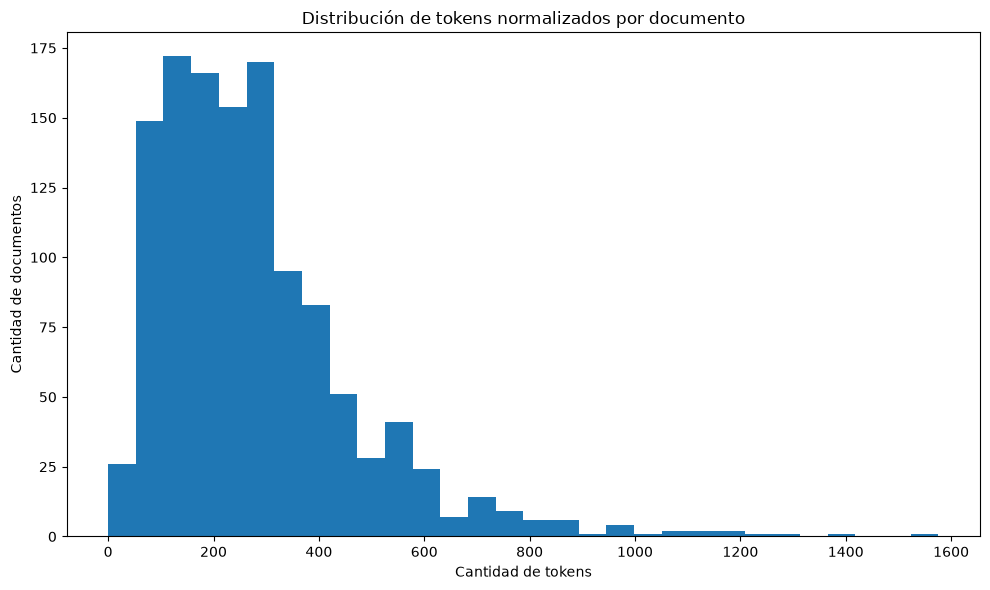

In [24]:
plt.figure(figsize=(10, 6))

plt.hist(
    corpus["cantidad_tokens_normalizados"],
    bins=30
)

plt.title(
    "Distribución de tokens normalizados por documento"
)

plt.xlabel("Cantidad de tokens")
plt.ylabel("Cantidad de documentos")

plt.tight_layout()
plt.show()

### Resultado del histograma

La mayoría de las noticias contiene aproximadamente entre **[240]** y **[280] tokens normalizados**.

El promedio fue de **[278.79] tokens por documento**, mientras que la mediana fue de **[243] tokens**.

También se observaron algunas noticias más largas que el resto. Estas aparecen en la parte derecha del histograma y pueden considerarse valores poco comunes dentro de la distribución.

## 5.5 Ley de Zipf

La Ley de Zipf indica que unas pocas palabras aparecen muchas veces, mientras que una gran cantidad de palabras aparecen pocas veces.

Donde:

- \(f(r)\) es la frecuencia de una palabra.
- \(r\) es la posición de la palabra en el ranking.
- \(k\) es la frecuencia de la palabra más común.

Para observar mejor esta relación, se utilizará una escala logarítmica en ambos ejes.

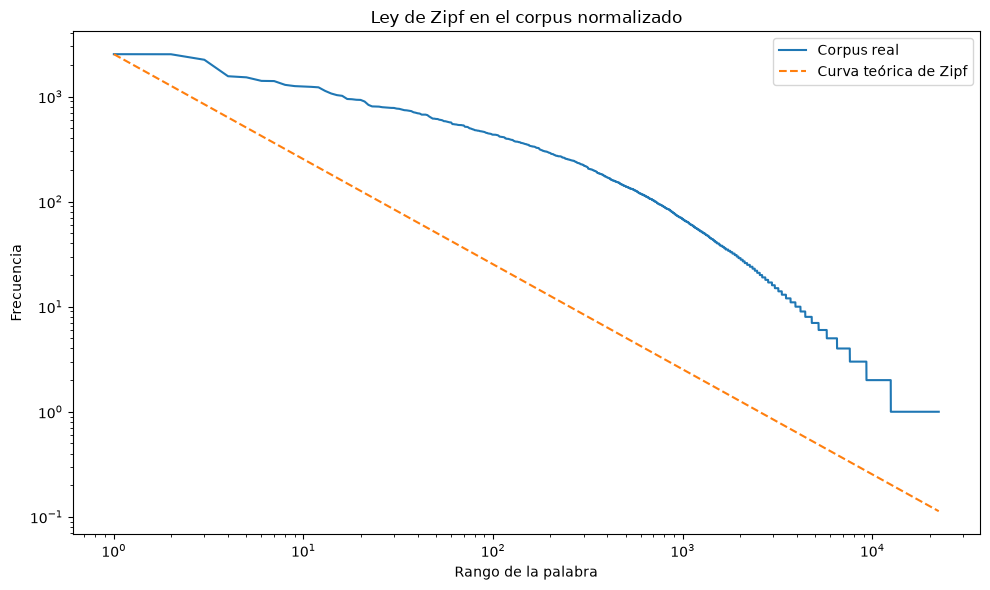

In [25]:
# Ordenar las frecuencias de mayor a menor
frecuencias_ordenadas = np.array(
    sorted(
        frecuencias_palabras.values(),
        reverse=True
    )
)

# Crear los rangos: 1, 2, 3, ...
rangos = np.arange(
    1,
    len(frecuencias_ordenadas) + 1
)

# Valor de k: frecuencia de la palabra más común
k = frecuencias_ordenadas[0]

# Curva teórica de Zipf
frecuencia_teorica = k / rangos


plt.figure(figsize=(10, 6))

# Curva real
plt.loglog(
    rangos,
    frecuencias_ordenadas,
    label="Corpus real"
)

# Curva teórica
plt.loglog(
    rangos,
    frecuencia_teorica,
    linestyle="--",
    label="Curva teórica de Zipf"
)

plt.title("Ley de Zipf en el corpus normalizado")
plt.xlabel("Rango de la palabra")
plt.ylabel("Frecuencia")

plt.legend()
plt.tight_layout()
plt.show()

### Comparación con la Ley de Zipf

La curva del corpus tiene una forma parecida a la curva teórica de Zipf.

Al inicio del gráfico se observa que unas pocas palabras tienen una frecuencia muy alta. Después, la frecuencia disminuye rápidamente y existe una gran cantidad de palabras que aparecen pocas veces.

Sin embargo, la curva real no es exactamente igual a la curva teórica. Esto puede ocurrir porque el corpus contiene una cantidad limitada de noticias, diferentes categorías y palabras propias de nombres, lugares o temas específicos.

Además, la eliminación de stopwords y la lematización cambian la distribución natural de las palabras.

## 5.6 Comparación de palabras por categoría

Se compararán las diez palabras más frecuentes de dos categorías diferentes.

Esta comparación permite observar qué palabras son más importantes en cada tipo de noticia y cómo cambia el vocabulario según el tema.

In [26]:
# Seleccionar las dos categorías con más documentos
categorias_comparadas = (
    corpus["Type"]
    .value_counts()
    .head(2)
    .index
    .tolist()
)

categoria_1 = categorias_comparadas[0]
categoria_2 = categorias_comparadas[1]

print(f"Primera categoría: {categoria_1}")
print(f"Segunda categoría: {categoria_2}")

Primera categoría: Macroeconomia
Segunda categoría: Alianzas


In [27]:
def palabras_frecuentes_categoria(
    dataframe,
    categoria,
    cantidad=10
):
    """
    Obtiene las palabras más frecuentes de una categoría.
    """

    documentos_categoria = dataframe.loc[
        dataframe["Type"] == categoria,
        "tokens_lematizados"
    ]

    tokens_categoria = [
        token
        for documento in documentos_categoria
        for token in documento
    ]

    frecuencias = Counter(tokens_categoria)

    tabla = pd.DataFrame(
        frecuencias.most_common(cantidad),
        columns=["Palabra", "Frecuencia"]
    )

    tabla.index = range(1, len(tabla) + 1)
    tabla.index.name = "Posición"

    return tabla


tabla_categoria_1 = palabras_frecuentes_categoria(
    corpus,
    categoria_1
)

tabla_categoria_2 = palabras_frecuentes_categoria(
    corpus,
    categoria_2
)

print(f"Palabras más frecuentes de: {categoria_1}")
display(tabla_categoria_1)

print(f"Palabras más frecuentes de: {categoria_2}")
display(tabla_categoria_2)

Palabras más frecuentes de: Macroeconomia


,Palabra,Frecuencia
Posición,,
1,inflación,1331
2,precio,1016
3,año,1003
4,poder,679
5,bbva,547
6,mes,530
7,mayor,523
8,tasa,516
9,país,456


Palabras más frecuentes de: Alianzas


,Palabra,Frecuencia
Posición,,
1,alianza,427
2,país,369
3,poder,341
4,colombia,291
5,millón,274
6,año,261
7,nuevo,256
8,empresa,237
9,hacer,203


In [28]:
comparacion_categorias = pd.DataFrame({
    f"Palabra - {categoria_1}":
        tabla_categoria_1["Palabra"].values,

    f"Frecuencia - {categoria_1}":
        tabla_categoria_1["Frecuencia"].values,

    f"Palabra - {categoria_2}":
        tabla_categoria_2["Palabra"].values,

    f"Frecuencia - {categoria_2}":
        tabla_categoria_2["Frecuencia"].values
})

comparacion_categorias.index = range(
    1,
    len(comparacion_categorias) + 1
)

comparacion_categorias.index.name = "Posición"

display(comparacion_categorias)

,Palabra - Macroeconomia,Frecuencia - Macroeconomia,Palabra - Alianzas,Frecuencia - Alianzas
Posición,,,,
1,inflación,1331,alianza,427
2,precio,1016,país,369
3,año,1003,poder,341
4,poder,679,colombia,291
5,bbva,547,millón,274
6,mes,530,año,261
7,mayor,523,nuevo,256
8,tasa,516,empresa,237
9,país,456,hacer,203


### Comparación entre categorías

Se compararon las categorías **[Maccroeconomia]** y **[Alianzas]**.

En la categoría **[Macroeconomia]** destacaron palabras como **`[inflacion]`**, **`[precio]`** y **`[año]`**. Estas palabras se relacionan principalmente con **[temas de economia]**.

En la categoría **[Alianzas]** aparecieron con mayor frecuencia palabras como **`[alianza]`**, **`[pais]`** y **`[poder]`**. Estas se relacionan principalmente con **[temas de globalizacion]**.

La comparación muestra que cada categoría utiliza palabras diferentes porque sus noticias tratan temas distintos.

## 5.7 Nube de palabras

La nube de palabras muestra de forma visual las palabras más frecuentes del corpus normalizado.

Las palabras que aparecen con un tamaño más grande son las que tienen una mayor frecuencia.

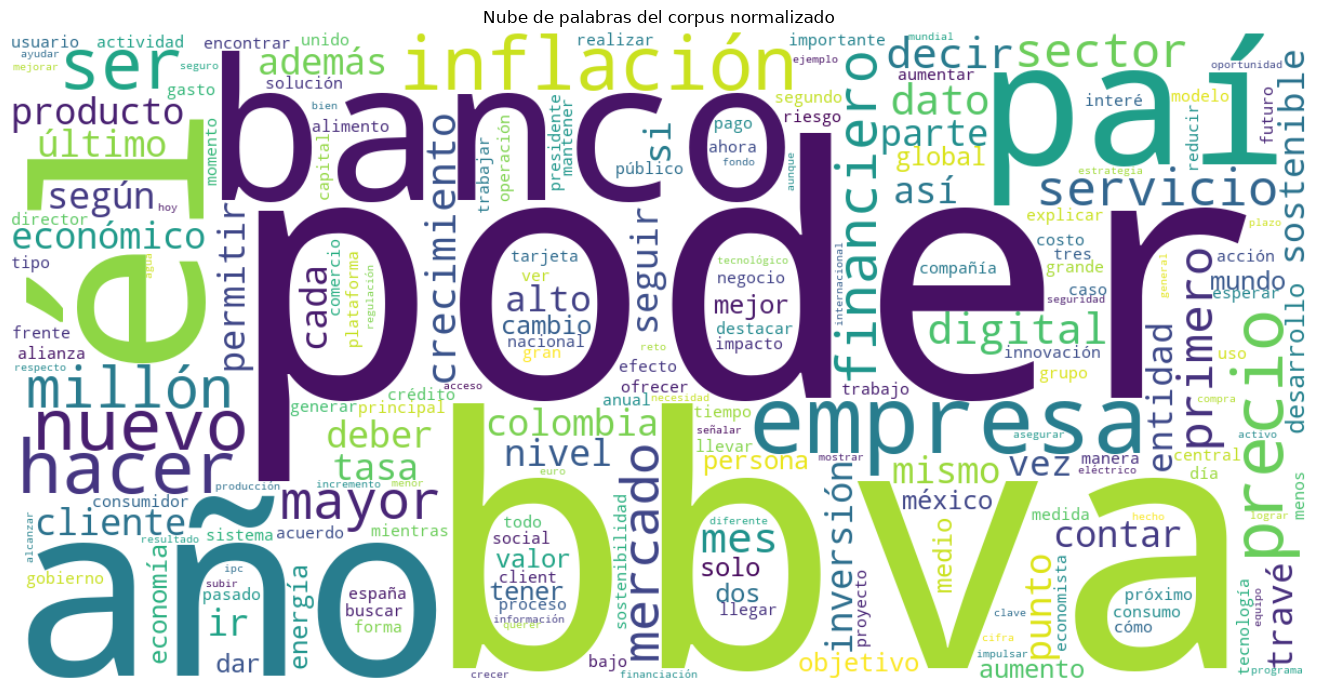

In [29]:
# Convertir todos los tokens normalizados en un solo texto
texto_normalizado_completo = " ".join(
    tokens_normalizados
)

# Crear la nube de palabras
nube_palabras = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False
).generate(texto_normalizado_completo)

# Mostrar la nube
plt.figure(figsize=(14, 7))

plt.imshow(
    nube_palabras,
    interpolation="bilinear"
)

plt.axis("off")
plt.title("Nube de palabras del corpus normalizado")

plt.tight_layout()
plt.show()

### Resultado de la nube de palabras

La nube permite identificar rápidamente las palabras que tienen mayor presencia dentro del corpus.

Las palabras que aparecen con mayor tamaño son **`[poder]`**, **`[bbva]`** y **`[año]`**.

Estas palabras coinciden con varios de los resultados obtenidos en la tabla de frecuencias y representan algunos de los temas más comunes dentro de las noticias analizadas.

In [30]:
from pathlib import Path

ruta_salida = Path("corpus_normalizado.pkl")

corpus.to_pickle(ruta_salida)

print(f"Corpus normalizado guardado en: {ruta_salida.resolve()}")
print(f"Documentos guardados: {len(corpus):,}")

Corpus normalizado guardado en: /Users/josetanchez/Desktop/NLP-Labs-JoseTanchez/Lab1/corpus_normalizado.pkl
Documentos guardados: 1,217
